# Hybrid Simulation: Event Chain Handling

In the bigger picture of the simulation of cyber-physical systems, hybrid systems play a crucial role as they combine continuous dynamics with discrete events.

Continuous dynamics are typically described by differential equations, while discrete events can represent sudden changes in the system, such as switching operations or fault occurrences.

While continuous dynamics signals are present throughout the simulation, discrete events can occur at specific time instants, potentially causing abrupt changes in the system's state.

If one discrete event triggers another event at the same time instant, this situation is referred to as an **event chain**.

This tutorial demonstrates how an event chanin can be set up in a hybrid system simulation and shows how the the `HybridAlgorithm` detects and resolves multiple events occurring at the same time.

## Overview

In this test case, we create a hybrid system where **a first event triggers a second event at the same real time instant**.
This is called an **event chain**.

We introduce the concept of **Dense Time**, where multiple events can occur at the same real time but are ordered sequentially.
Dense Time can be represented as pairs $(t, d)$ where $t$ is the real time and $d$ is the micro-step index.
The first event will be handled at dense time $(t_\text{e}, 0)$ and the second event at dense time $(t_\text{e}, 1)$.
The event chain can be seen in the system graph below.

## Learning Goals

- Understand how to set up an event chain in a hybrid system simulation.
- Understand the concept of Dense Time in hybrid simulations.
- Learn how the `HybridAlgorithm` resolves multiple events occurring at the same time.

## Prerequisites and Setup

We require the following packages:
- `syssimx`
- `numpy`
- `matplotlib`
- `graphviz` (for visualization)

In [16]:
import matplotlib.pyplot as plt
import numpy as np

from syssimx.core.base import CoSimComponent
from syssimx.core.events import Event
from syssimx.core.port import PortSpec, PortType
from syssimx.system.connection import EventConnection
from syssimx.system.system import System
from syssimx.viz.sysgraph import SystemGraphVisualizer

## Implementation

### Common Functionality of the Components

All components contain a linearly eveolving state vaiable which eveolves according to the following state equation:

  $$ x(t) = x_0 + v \cdot (t - t_0) $$

### `HybridSource`Component

- Acts as an **event source** with a linearly evolving state variable
- Provides the methods required for rollback `snapshot_state()` and `restore_state()`

In [17]:
class HybridSource(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Event Source")
        self.x0 = x0
        self.v = v
        self.t0 = t0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(self, t: float | None = None) -> None:
        self.outputs["x"].set(self.x, t=t)

    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot, t) -> None:
        self.t = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v = snapshot["v"]

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()

### `HybridCombi` Component

- *Combi* component that doubles the value of its velocity `v`when an event is received for the event port `v_double`
- Provides the methods required for rollback `snapshot_state()` and `restore_state()`

In [18]:
class HybridCombi(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Combi")
        self.x0 = x0
        self.v_prev = v
        self.v_curr = v
        self.t0 = t0
        self.v_changed = False  # flag for velocity change
        self.input_specs.update(
            {"v_double": PortSpec(name="v_double", type=PortType.EVENT, direction="in")}
        )
        self.output_specs.update(
            {
                "x": PortSpec(name="x", type=PortType.REAL, direction="out"),
            }
        )

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v_curr * (t + dt - self.t0)

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ) -> None:
        self.outputs["x"].set(self.x, t=t)

    def snapshot_state(self):
        return {
            "t": self.t,
            "x": self.x,
            "v": self.v_curr,
            "v_prev": self.v_prev,
            "t0": self.t0,
        }

    def _handle_events_internal(self, event_names, t):
        if "v_double" in event_names:  # Fixed condition
            self.t0 = t
            self.x0 = self.x
            self.v_prev = self.v_curr
            self.v_curr = 2 * self.v_curr

    def restore_state(self, snapshot, t) -> None:
        self.t = t
        self.t0 = snapshot["t0"]
        self.x = snapshot["x"]
        self.v_curr = snapshot["v"]
        self.v_prev = snapshot.get("v_prev", self.v_curr)

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()

### `HybridListener` Component

- Pure event listener component that reacts on the event `v_change` by inverting its velocity `v`
- Does not provide rollback functionality and cannot be used as event source

In [19]:
class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)
    """

    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0
        self.v = v
        self.t0 = t0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})
        self.input_specs.update(
            {"v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in")}
        )

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ) -> None:
        self.outputs["x"].set(self.x, t=t)

    def _handle_events_internal(self, event_names, t):
        if "v_change" in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v

    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}

### Instantiation of Components

We instantiate the components such that the `HybridSource` triggers the starting event at $t_\text{e}\approx 0.333 \, \mathrm{s}$

In [20]:
src_comp = HybridSource(name="Source", x0=-2 / 3, v=2)
combi_comp = HybridCombi(name="Combi", x0=2 / 3, v=-1)
listener_comp = HybridListener(name="Listener", x0=0.0, v=3.0)

components = [src_comp, combi_comp, listener_comp]

### Defining Event Connections

We define the event indicator functions for the `HybridSource` and `HybridCombi` components.

The `HybridSource` triggers an event when its state variable `x` crosses zero.

The `HybridCombi` triggers an event when its velocity `v` changes.

In [21]:
def event_indicator_zero_crossing(comp: HybridSource) -> float:
    return comp.x

def event_indicator_v_change(comp: HybridCombi) -> float:
    return -1.0 if comp.v_curr != comp.v_prev else 1.0

For our `HybridSource` component, we define `direction=1` to only detect zero-crossings from negative to positive values.

For our `HybridCombi` component, we define `direction=-1`. Since the indicator function returns `-1.0` when the velocity has changed and `1.0` otherwise, this setting ensures that an event is triggered when the velocity changes.

In [22]:
src_comp.add_event_indicator(
    name="v_double", func=event_indicator_zero_crossing, direction=1
)
combi_comp.add_event_indicator(
    name="v_change", func=event_indicator_v_change, direction=-1
)

The `EventConnection`s are defined according to the event names and event input port names.

In [23]:
event_connection_1 = EventConnection(
    src_comp=src_comp.name,
    src_port="v_double",
    dst_comp=combi_comp.name,
    dst_port="v_double",
)

event_connection_2 = EventConnection(
    src_comp=combi_comp.name,
    src_port="v_change",
    dst_comp=listener_comp.name,
    dst_port="v_invert",
)

event_connections = [event_connection_1, event_connection_2]

### Creating the System

In [24]:
system = System(name="Hybrid Event Chain System")

for comp in components:
    system.add_component(comp)

for ev_conn in event_connections:
    system.add_event_connection(ev_conn)

system.initialize(t0=0.0)
system.algorithm.verbose = True
system.algorithm.record_internal_steps = True

### Visualizing the System Graph

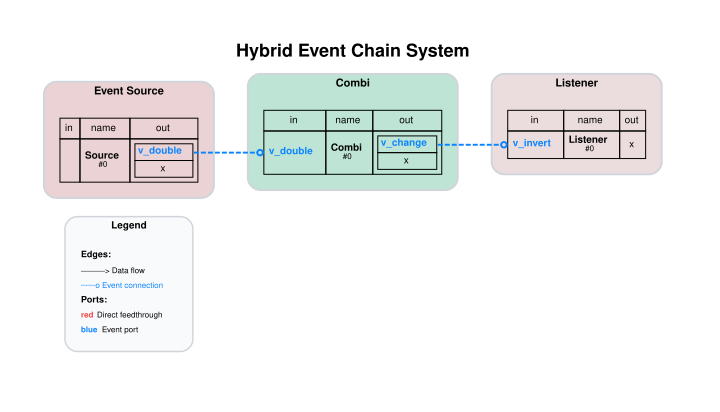

In [25]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize(filename="hybrid_event_chain_system_graph.svg")

In [26]:
print("Component Classification:")
for classification, components in system.classify_components().items():
    print(f" - {classification}: {[component.name for component in components]}")

print(f"\nUsing Algorithm: {system.algorithm.name}\n")

Component Classification:
 - event_sources: ['Source', 'Combi']
 - event_listeners: ['Combi', 'Listener']
 - continuous_only: []

Using Algorithm: Hybrid-Algorithm



### Running the Simulation

In [27]:
system.run(t0=0.0, tf=1.0, dt=0.05)

[Hybrid] Time: 0.3500 s
[Hybrid] Events detected in interval [0.30000000, 0.35000000]
[Hybrid] Crossings: [('Source', 'v_double')]
[Hybrid] Indicator for Source.v_double = 5.08626302e-07
[Hybrid] Indicator for Combi.v_change = 1.00000000e+00
[Hybrid] Initial events to handle: [('Source', 'v_double')]
[Hybrid] Located at t=(0.33333359, 0)
[Hybrid] Events to handle at t=(0.33333359, 0): [('Source', 'v_double')]
[Hybrid] Already handled events: set()
[Hybrid] Handling events at (0.33333359, 0): [('Source', 'v_double')]
[Hybrid] Events grouped by component for handling: {'Combi': ['v_double'], 'Listener': []}
[Hybrid] New events detected after handling: [('Combi', 'v_change')]
[Hybrid] Already handled events: {('Source', 'v_double', np.float64(0.333334))}
[Hybrid] Handling events at (0.33333359, 1): [('Combi', 'v_change')]
[Hybrid] Events grouped by component for handling: {'Combi': [], 'Listener': ['v_change']}

[Hybrid] End of event window


The log output of the simulation shows the detection and handling of the event chain at dense time $(t_\text{e}, 0)$ and $(t_\text{e}, 1)$ with $t_\text{e} \approx 0.333 \, \mathrm{s}$.

The first event is triggered by the `HybridSource` component when its state variable `x` crosses zero. This event is handled at dense time $(t_\text{e}, 0)$, causing the `HybridCombi` component to double its velocity `v`.

After the first event is handled, the `HybridCombi` component's velocity `v` changes, triggering the second event at dense time $(t_\text{e}, 1)$. This event is handled by the `HybridListener` component, which inverts its velocity `v`.

After the handling of both events in the event chain, the simulation continues with the updated states of the components.

### Retrieving History

In [28]:
time_src, data_src = src_comp.get_history_arrays()
x_src = data_src["x"]

time_combi, data_combi = combi_comp.get_history_arrays()
x_combi = data_combi["x"]

time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener["x"]

event_history = system.history.get_all_event_histories()
trigger_times_1 = event_history.get((src_comp.name, "v_double"), [])
trigger_times_2 = event_history.get((combi_comp.name, "v_change"), [])

trigger_time_1 = trigger_times_1[0].t
trigger_time_2 = trigger_times_2[0].t

### Visualizing the Results

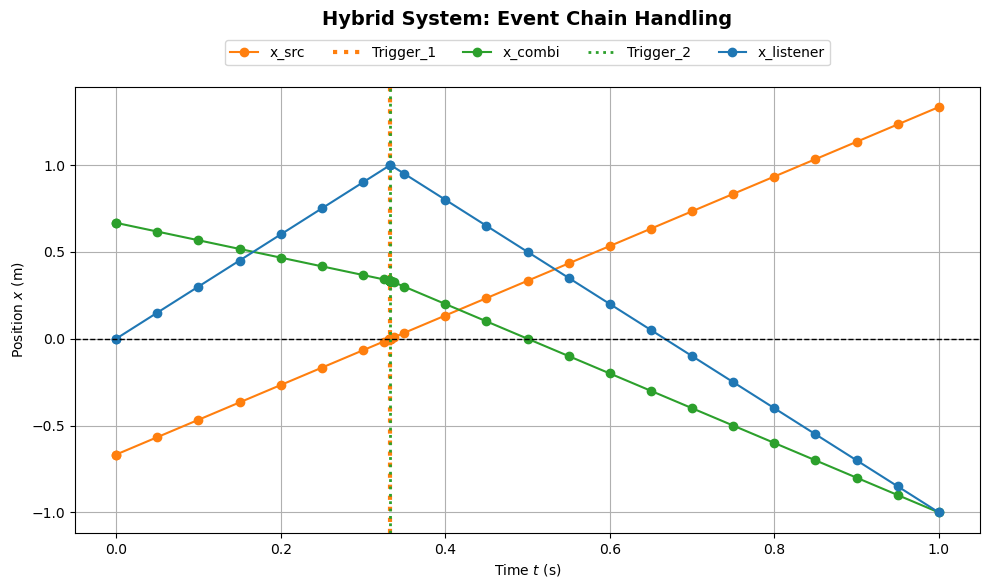

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(time_src, x_src, label="x_src", color="tab:orange", marker="o", linestyle="-")
plt.axvline(trigger_time_1, color="tab:orange", linestyle=":", label="Trigger_1", linewidth=3)
plt.plot(time_combi, x_combi, label="x_combi", color="tab:green", marker="o", linestyle="-")
plt.axvline(trigger_time_2, color="tab:green", linestyle=":", label="Trigger_2", linewidth=2)
plt.plot(time_listener, x_listener, label="x_listener", color="tab:blue", marker="o", linestyle="-")
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Hybrid System: Event Chain Handling", fontsize=14, fontweight="bold", y=1.12)
plt.xlabel("Time $t$ (s)")
plt.ylabel("Position $x$ (m)")
plt.grid()
plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.show()

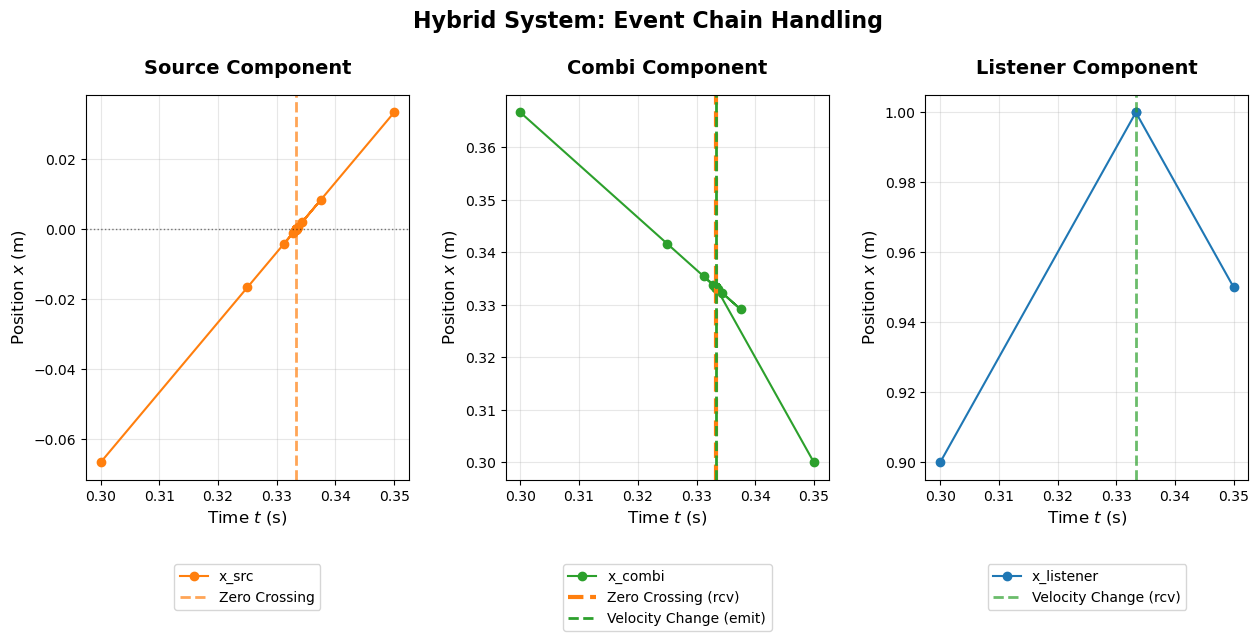

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

window = 0.05

# Create individual masks for each component's time array
mask_src = (time_src >= (trigger_time_1 - window)) & (time_src <= (trigger_time_1 + window))
mask_combi = (time_combi >= (trigger_time_1 - window)) & (time_combi <= (trigger_time_2 + window))
mask_listener = (time_listener >= (trigger_time_1 - window)) & (time_listener <= (trigger_time_2 + window))

# Source component - zoom around first event
axs[0].plot(time_src[mask_src], x_src[mask_src], label="x_src", color="tab:orange", marker="o", linestyle="-", markersize=6)
axs[0].axvline(trigger_time_1, color="tab:orange", linestyle="--", label="Zero Crossing", linewidth=2, alpha=0.7)
axs[0].axhline(0, color="black", linestyle=":", linewidth=1, alpha=0.5)
axs[0].set_title("Source Component", fontsize=14, fontweight="bold", pad=15)
axs[0].set_ylabel("Position $x$ (m)", fontsize=12)
axs[0].set_xlabel("Time $t$ (s)", fontsize=12)
axs[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=10)
axs[0].grid(True, alpha=0.3)

# Combi component - zoom around both events
axs[1].plot(time_combi[mask_combi], x_combi[mask_combi], label="x_combi", color="tab:green", marker="o", linestyle="-", markersize=6)
axs[1].axvline(trigger_time_1, color="tab:orange", linestyle="--", label="Zero Crossing (rcv)", linewidth=3)
axs[1].axvline(trigger_time_2, color="tab:green", linestyle="--", label="Velocity Change (emit)", linewidth=2)
axs[1].set_title("Combi Component", fontsize=14, fontweight="bold", pad=15)
axs[1].set_ylabel("Position $x$ (m)", fontsize=12)
axs[1].set_xlabel("Time $t$ (s)", fontsize=12)
axs[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=10)
axs[1].grid(True, alpha=0.3)

# Listener component - zoom around second event
axs[2].plot(time_listener[mask_listener], x_listener[mask_listener], label="x_listener", color="tab:blue", marker="o", linestyle="-", markersize=6)
axs[2].axvline(trigger_time_2, color="tab:green", linestyle="--", label="Velocity Change (rcv)", linewidth=2, alpha=0.7)
axs[2].set_title("Listener Component", fontsize=14, fontweight="bold", pad=15)
axs[2].set_xlabel("Time $t$ (s)", fontsize=12)
axs[2].set_ylabel("Position $x$ (m)", fontsize=12)
axs[2].legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), fontsize=10)
axs[2].grid(True, alpha=0.3)

plt.suptitle("Hybrid System: Event Chain Handling", fontsize=16, fontweight="bold", y=1.05)
plt.subplots_adjust(wspace=0.3, hspace=0.4) 
plt.show()

The figure above shows the state variable `x` of all three components over time.

The `HybridSource` component's state variable `x` crosses zero at approximately $t \approx 0.333 \, \mathrm{s}$, triggering the first event.

The velocity change in the `HybridCombi` component can be seen in the change of the slope of its state variable `x` after the first event.

The `HybridListener` component's state variable `x` shows a change in slope after the second event, reflecting the inversion of its velocity `v`.

As the `HybridSource` and the `HybridCombi` components are event sources, both are involved in the rollback mechanism of the `HybridAlgorithm`. This can be seen in the multiple state restorations and re-evaluations of their states around the event time $t_\text{e} \approx 0.333 \, \mathrm{s}$.

## Conclusion

This tutorial demonstrated how to set up and simulate an event chain in a hybrid system using the `syssimx` library.

We defined custom event indicator functions for components to trigger events based on specific conditions.

We saw how the `HybridAlgorithm` detects and resolves multiple events occurring at the same real time instant by utilizing Dense Time.

In the next tutorial, we will explore an event more complex hybrid system involving multiple events occuring at the same `DenseTime`.